# Ontologies creation using NAIVE approaches

This notebook explores an initial approach to the challenge of ontology creation using large language models (LLMs). We will follow a simple heuristic to generate results and evaluate output:

1. **Input:** We start by providing a domain name and 5-10 terms related to the domain from which we wish to generate an ontology. This will expand to include a domain and topic, a definition for both, and eventually additional initial terms.
   
2. Given the input, we will request a large language model (in this case, ChatGPT-4o) to return a number (to be defined) of related terms.
   
3. Following initial thesis on calculation of semantic distance, we will request the model to calculate distance between terms. We will then test by removing or not removing terms with the lowest semantic distance and by requesting step 2 multiple times (distill).
   
4. Given the output of step 3, we will cluster results using hierarchical clustering.
   
5. Clusters will be used to serialize as RDF with a predicate "as-is" and the terms internally with "is-related". At this stage, we will also test requesting an LLM to generate text using the given terms and the domain/topic to test the extraction of different relations.
   
6. We will plot the ontology.
   
7. Compare the output with similar results from dbpedia.org.


### Prompts used for semantic distance calculations

Based out of initial work we will use the following prompts which have be shown to return good results. For this initial experiment we will only use english prompts to isolate tasks. we don't wish to analyse model capacity for task execution on a multi language environment.

```txt
In this survey you’ll be asked to rate quantitatively, on a scale, the intensity of the semantic relatedness between pairs of affective words. Please, before starting, read carefully the instructions and the examples provided. 

The question we’re asking is: how much related are the two words? Vaguely related words should be scored with lower values, and strongly related words with higher values. Please note that opposite words frequently present high values of relatedness.

For example, the words ’modest’ and ’smart’ don’t seem very related. ’Conceal’ and ’mask’ seem very related. ’Confident’ is highly related with itself. ’Violent’ and ’pacific’, being opposite words, are frequently related, just like ’happiness’ and ’sadness’. 

Examples: 
* modest, smart: 1,
* conceal, mask: 4 
* confident, confident: 5 
* violent, pacific: 4 
* happiness, sadness: 5

Please rate from 0 to 4 the semantic relatedness of the following pairs of words, with 0 indicating words not related at all and 4 indicating very related words: 
apple, galaxy
fault, system
champion, winner 
town, city

```

In [2]:
import sys
import pandas as pd
import json
from pathlib import Path


sys.path.insert(0, str(Path.cwd().parent))
from src.services import ChatGpt

In [3]:
# endpoint = "https://api.iaedu.pt/agent-chat//api/v1/agent/cmamvd3n40000c801qeacoad2/stream"

# data = {
#     "channel_id": "cmj1i57292iz9lq01goukbuuv",
#     "thread_id": "mpa9gz8d5JYEesDE_gqHf",
#     "user_info": "{}",
#     "message": "Can you provide a summary of the main topics covered in high school mathematics?",
#     # Optional fields:
#     # "user_id": "your_user_id",
#     # "user_context": '{"key": "value"}',
# }

# headers = {
#     "x-api-key": os.getenv("IAEDU_API_KEY"),
# }

# response = requests.post(endpoint, data=data, headers=headers, stream=True)

# for chunk in response.iter_content(chunk_size=None, decode_unicode=True):
#     if chunk:
#         print(chunk, end="", flush=True)

---

## Experiment 1: 

**Description:** 

1. use a domain name and 10 terms related and request a term cloud. 
2. Request semantic distance between terms
3. No destil
4. Run hierarchy cluster
5. serialize into rdf

In [ ]:
agent = ChatGpt()
agent.model = "gpt-4o-mini"

terms_list_str = agent.chat(
    instructions="You are a taxonomy and ontology expert. Provide concise and accurate responses based on the user's queries.",
    input="""
        Provide a list of 20 categories, terms or words closely related to domain or topic and using the provided terms as reference.
        
        - the domain or topic is: cinema
        - the provided terms are: 
            start trek, spoke, vulcan, klingon, enterprise
        
        Your output should be a json array with only the category names, without any additional text. 
        This categories should include the given terms and be closely related to the domain or topic.
        Do not encapsulate the output in code blocks.
        
        Example output:
        [
            "category1",
            "category2",
            ...            "category100"
        ]
        
    """
)

In [5]:
# Clean output. 
terms_list_json = json.loads(terms_list_str)
terms_list_df = pd.DataFrame(terms_list_json, columns=["category"])
print(terms_list_df.head(10))
print(terms_list_df.tail(10))

              category
0      science fiction
1    space exploration
2             futurism
3               aliens
4  interstellar travel
5             starship
6    galactic politics
7           warp drive
8      virtual reality
9             androids
             category
10  cultural conflict
11        time travel
12        cybernetics
13      teleportation
14      sci-fi fandom
15      crew dynamics
16      space battles
17         multiverse
18       cosmonautics
19      legacy series


In [6]:
# Cartesian product with provided terms
terms_pair = pd.merge(terms_list_df, terms_list_df, how='cross')
terms_pair = terms_pair.drop(terms_pair[terms_pair['category_x'] == terms_pair['category_y']].index) # We don't need to analyse a term with itself

In [7]:
## Calculate similarity for each pair
similarity_df = agent.get_similarity(terms_pair)

In [16]:
similarity_df.groupby("similarity").size().reset_index(name='counts')

,similarity,counts
0,2,6
1,3,246
2,4,128


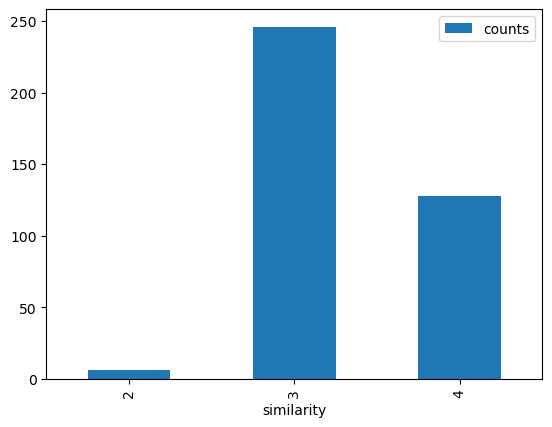

In [18]:
( 
    similarity_df
        .groupby("similarity")
        .size()
        .reset_index(name='counts')
        .plot(kind='bar', x='similarity', y='counts')
);

In [19]:
from sklearn.cluster import AgglomerativeClustering 
from scipy.cluster.hierarchy import dendrogram, linkage

In [22]:
similarity_df['category_x'].unique()

array(['science fiction', 'space exploration', 'futurism', 'aliens',
       'interstellar travel', 'starship', 'galactic politics',
       'warp drive', 'virtual reality', 'androids', 'cultural conflict',
       'time travel', 'cybernetics', 'teleportation', 'sci-fi fandom',
       'crew dynamics', 'space battles', 'multiverse', 'cosmonautics',
       'legacy series'], dtype=object)

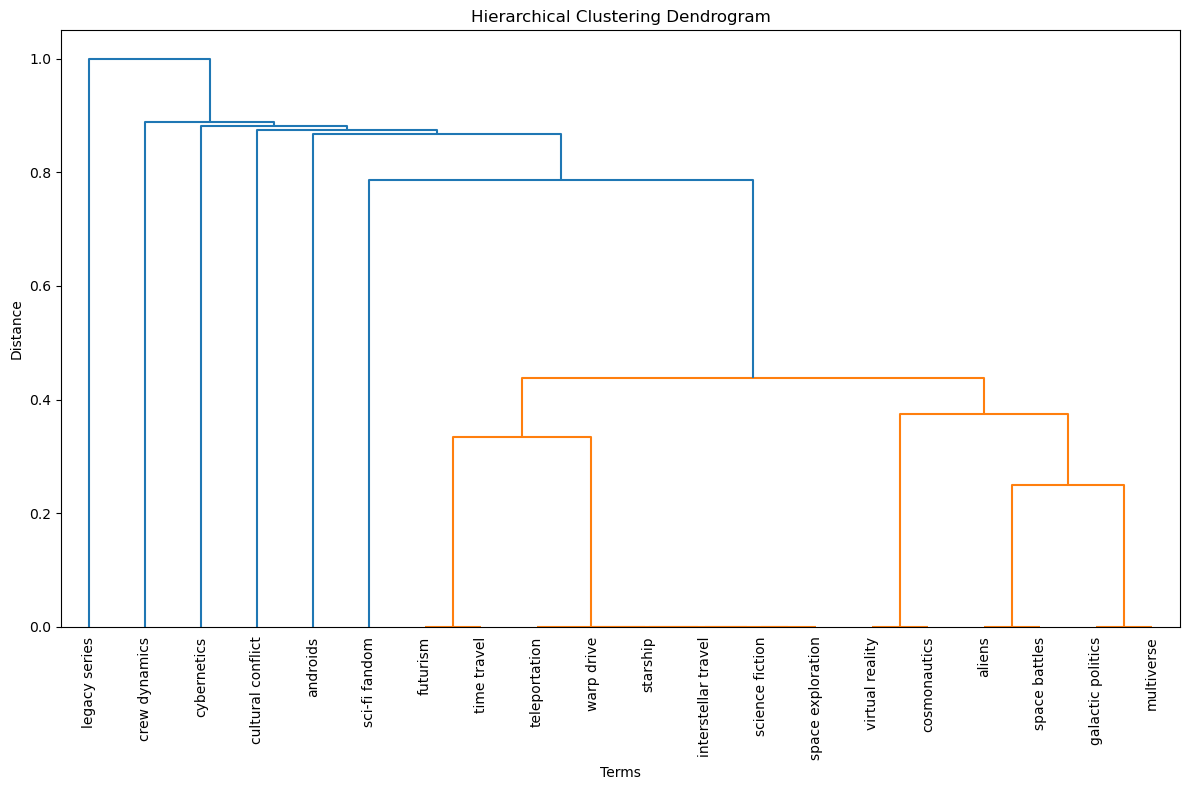

In [21]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# Assuming similarity_df has columns: category_x, category_y, similarity

# Step 1: Convert similarity to distance (4 - similarity, so 0 similarity = 4 distance)
similarity_df['distance'] = 4 - similarity_df['similarity']

# Step 2: Get unique terms
terms = pd.unique(similarity_df[['category_x', 'category_y']].values.ravel())
n = len(terms)

# Step 3: Create a square distance matrix
distance_matrix = pd.DataFrame(np.zeros((n, n)), index=terms, columns=terms)

for _, row in similarity_df.iterrows():
    distance_matrix.loc[row['category_x'], row['category_y']] = row['distance']
    distance_matrix.loc[row['category_y'], row['category_x']] = row['distance']

# Diagonal is 0 (distance to self)
np.fill_diagonal(distance_matrix.values, 0)

# Step 4: Convert to condensed distance matrix for linkage
condensed_dist = squareform(distance_matrix.values)

# Step 5: Perform hierarchical clustering
Z = linkage(condensed_dist, method='average')

# Step 6: Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram(Z, labels=terms, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Terms')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()